In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

## Task 1 — Dataset Understanding

In [20]:
# Load Dataset
df = pd.read_csv("customer_support_text_classification.csv")
print(df.head())

  ticket_id channel                                   customer_message  \
0  TKT00001    chat  I need information about the payment process. ...   
1  TKT00002   phone      I need information about the payment process.   
2  TKT00003   email  The refund process was fast and convenient. I ...   
3  TKT00004  social  My refund is still pending and this experience...   
4  TKT00005    chat   Please tell me how to update my account details.   

  sentiment_label  word_count  urgent_flag  
0         neutral          18            1  
1         neutral           7            0  
2        positive          12            0  
3        negative          15            1  
4         neutral           9            0  


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   ticket_id         1500 non-null   str  
 1   channel           1500 non-null   str  
 2   customer_message  1500 non-null   str  
 3   sentiment_label   1500 non-null   str  
 4   word_count        1500 non-null   int64
 5   urgent_flag       1500 non-null   int64
dtypes: int64(2), str(4)
memory usage: 70.4 KB


In [22]:
# Number of Records
print("Total Records:", len(df))

Total Records: 1500


In [23]:
# Target Labels / Classes
print(df["sentiment_label"].unique())

<StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str


In [24]:
# Class Distribution
print(df["sentiment_label"].value_counts())

sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


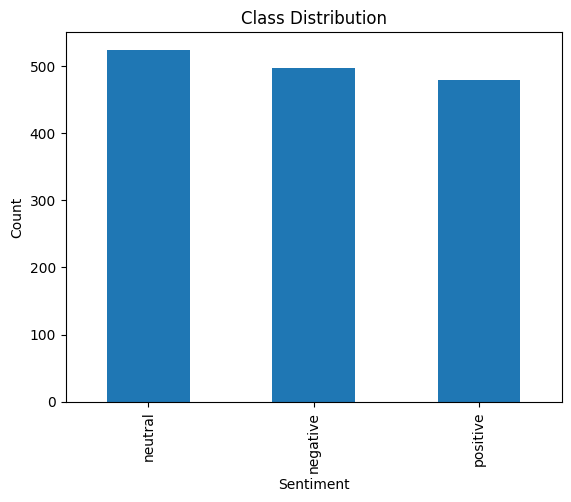

In [25]:
df["sentiment_label"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [26]:
# Sample Text Records
print(df["customer_message"].head())
# Average Text Length
df["text_length"] = df["customer_message"].apply(len)
print("Average Text Length:", df["text_length"].mean())

0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
3    My refund is still pending and this experience...
4     Please tell me how to update my account details.
Name: customer_message, dtype: str
Average Text Length: 72.75666666666666


## Task 2 — Text Preprocessing

In [27]:
# Required Libraries 
import re
import nltk

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [28]:
# Text Cleaning Function
stop_words = set(stopwords.words('english'))

def preprocess_text(text):

    # Lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)

df["clean_text"] = df["customer_message"].apply(preprocess_text)

print(df[["customer_message", "clean_text"]].head())

                                    customer_message  \
0  I need information about the payment process. ...   
1      I need information about the payment process.   
2  The refund process was fast and convenient. I ...   
3  My refund is still pending and this experience...   
4   Please tell me how to update my account details.   

                                          clean_text  
0  need information payment process ticket number...  
1                   need information payment process  
2  refund process fast convenient appreciate quic...  
3  refund still pending experience frustrating ti...  
4                 please tell update account details  


## Task 3 — Text Vectorization

Why Text Must Be Converted into Vectors

Machine learning models cannot understand raw text directly because models operate using numerical computations.
Text vectorization converts words into mathematical representations so algorithms can detect patterns, relationships, and meanings.

Examples:

- "refund pending" → numerical vector
- "payment failed" → numerical vector

Without vectorization, models cannot process language data.

In [29]:
# TF-IDF Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["clean_text"]).toarray()

y = df["sentiment_label"]

## Task 4 — Baseline Model

In [30]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
# Logistic Regression Model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

#Predictions
y_pred = model.predict(X_test)

In [32]:
# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



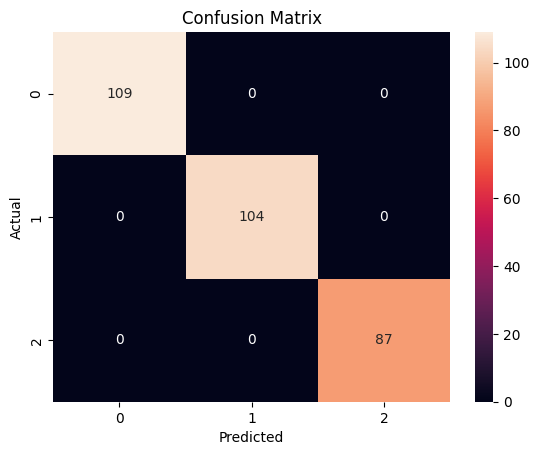

In [33]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Task 5 — Sequence Model (LSTM)

Traditional TF-IDF ignores word order.

Example:

- "not good"
- "good"

TF-IDF may treat both similarly.

Sequence models solve this by preserving word order.

In [34]:
# Tokenizer-Based Sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [35]:
# Tokenization
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df["clean_text"])
sequences = tokenizer.texts_to_sequences(df["clean_text"])

In [36]:
# Padding
max_len = 20
X_seq = pad_sequences(sequences, maxlen=max_len)

In [37]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y_seq = encoder.fit_transform(df["sentiment_label"])

In [38]:
# LSTM Architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential()

# Embedding Layer
model.add(Embedding(input_dim=5000, output_dim=64, input_length=max_len))

# LSTM Layer
model.add(LSTM(64))

# Output Layer
model.add(Dense(3, activation='softmax'))

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

e:\massai\codes\assignments\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [39]:
# Model Training
X_train, X_test, y_train, y_test = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    random_state=42
)

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.6575 - loss: 0.9369 - val_accuracy: 0.9967 - val_loss: 0.5234
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9892 - loss: 0.1801 - val_accuracy: 1.0000 - val_loss: 0.0271
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 1.0000 - loss: 0.0084 - val_accuracy: 1.0000 - val_loss: 0.0031
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 0.0011


In [40]:
"My refund is still pending"

'My refund is still pending'

## Task 6 — Attention and Transformer Reflection

**Why RNNs Struggle with Long-Term Dependencies**

RNNs process sequences step-by-step.
During long sequences, early information gradually fades because of vanishing gradients.
This makes remembering distant words difficult.

**How LSTMs Help**

LSTMs introduce memory cells and gates:

Forget gate
Input gate
Output gate

These mechanisms allow important information to persist longer.

**What Attention Solves**

Attention allows the model to focus on important words directly instead of relying only on sequential memory.

Example:

`"The refund was delayed but the support team was helpful."`

Attention helps identify important context words like:

delayed
helpful

**Why Transformers Are Important**

Transformers:

process all words in parallel
use self-attention
capture long-range dependencies efficiently
train faster than RNNs

Modern Generative AI systems like:

` OpenAI GPT,
Google BERT, 
Meta LLaMA `

are based on transformer architectures.